In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [13]:
df = pd.read_csv("../Day024/Data/PowerGeneration.csv")
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


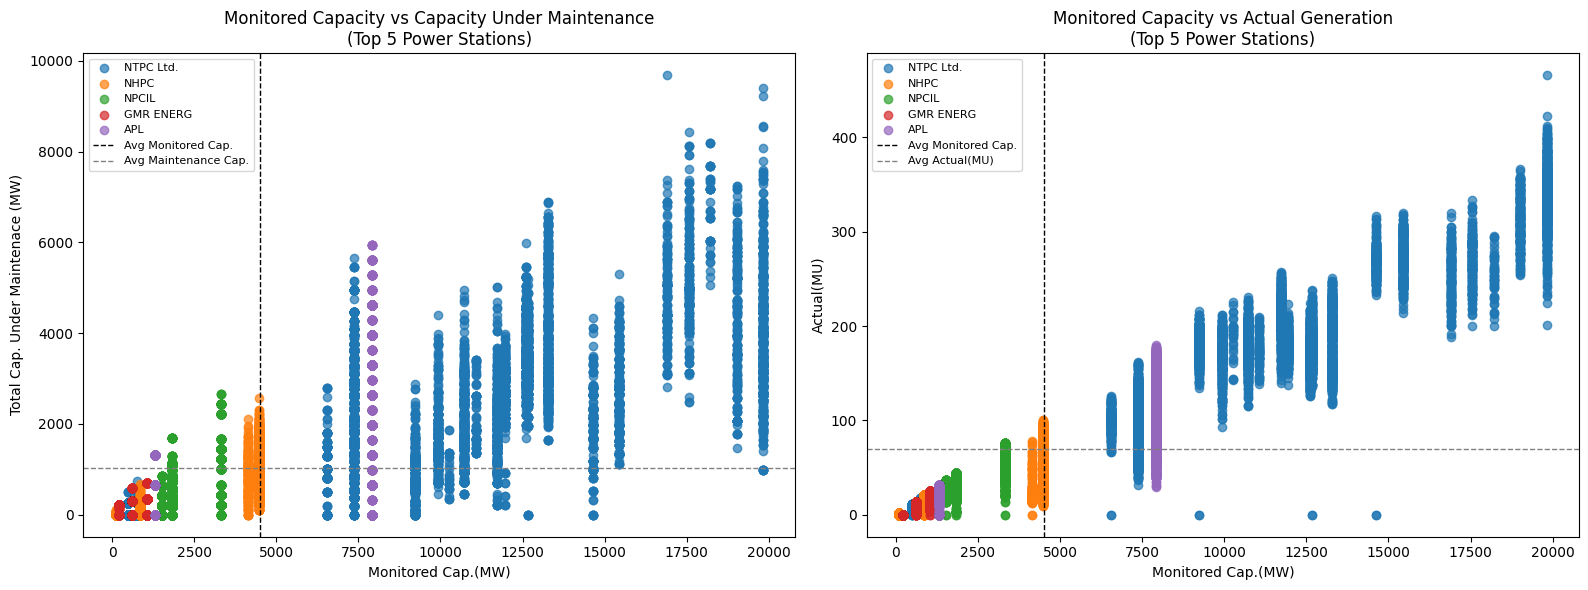

In [4]:
# ---- 2. Find the top 5 most frequent power stations ----
top5_stations = df["Power Station"].value_counts().head(5).index.tolist()
df_top5 = df[df["Power Station"].isin(top5_stations)]

# ---- 3. Assign a distinct color to each power station ----
colors = plt.cm.tab10.colors   # a set of 10 distinct colors, we just need 5
station_colors = {station: colors[i] for i, station in enumerate(top5_stations)}

# ---- 4. Create the subplots (1 row, 2 columns) ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# Chart 1: Monitored Cap.(MW) vs Total Cap. Under Maintenace (MW)
# ============================================================
ax1 = axes[0]

for station in top5_stations:
    subset = df_top5[df_top5["Power Station"] == station]
    ax1.scatter(
        subset["Monitored Cap.(MW)"],
        subset["Total Cap. Under Maintenace (MW)"],
        color=station_colors[station],
        label=station,
        alpha=0.7
    )

# average lines
x_mean1 = df_top5["Monitored Cap.(MW)"].mean()
y_mean1 = df_top5["Total Cap. Under Maintenace (MW)"].mean()
ax1.axvline(x_mean1, color="black", linestyle="--", linewidth=1, label="Avg Monitored Cap.")
ax1.axhline(y_mean1, color="gray", linestyle="--", linewidth=1, label="Avg Maintenance Cap.")

ax1.set_xlabel("Monitored Cap.(MW)")
ax1.set_ylabel("Total Cap. Under Maintenace (MW)")
ax1.set_title("Monitored Capacity vs Capacity Under Maintenance\n(Top 5 Power Stations)")
ax1.legend(fontsize=8)

# ============================================================
# Chart 2: Monitored Cap.(MW) vs Actual(MU)
# ============================================================
ax2 = axes[1]

for station in top5_stations:
    subset = df_top5[df_top5["Power Station"] == station]
    ax2.scatter(
        subset["Monitored Cap.(MW)"],
        subset["Actual(MU)"],
        color=station_colors[station],
        label=station,
        alpha=0.7
    )

# average lines
x_mean2 = df_top5["Monitored Cap.(MW)"].mean()
y_mean2 = df_top5["Actual(MU)"].mean()
ax2.axvline(x_mean2, color="black", linestyle="--", linewidth=1, label="Avg Monitored Cap.")
ax2.axhline(y_mean2, color="gray", linestyle="--", linewidth=1, label="Avg Actual(MU)")

ax2.set_xlabel("Monitored Cap.(MW)")
ax2.set_ylabel("Actual(MU)")
ax2.set_title("Monitored Capacity vs Actual Generation\n(Top 5 Power Stations)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plots/scatter_top5_power_stations.png", dpi=300, bbox_inches="tight")
plt.show()

### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

In [5]:
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


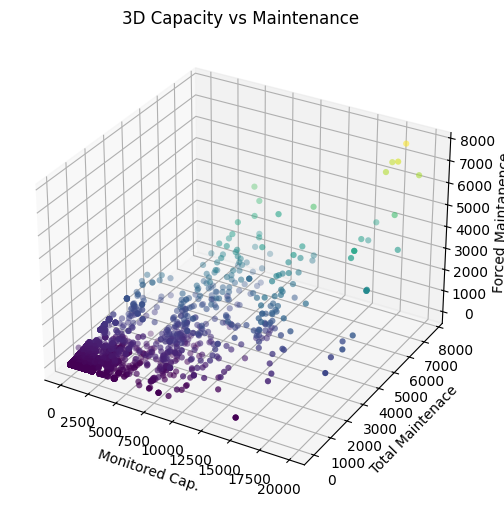

In [15]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Fast Vectorized Clean (Avoid .apply loops)
cols = ['Monitored Cap.(MW)', 'Total Cap. Under Maintenace (MW)', 'Forced Maintanence(MW)']
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

plot_df = df[cols].dropna()

# OPTIONAL: If rows > 5,000, sample it for instant speed!
if len(plot_df) > 5000:
    plot_df = plot_df.sample(5000, random_state=42)

# 2. Fast 3D Plot Setup
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Lightweight scatter call (No edgecolors, no raster loops, fast simple markers)
ax.scatter3D(
    plot_df['Monitored Cap.(MW)'],
    plot_df['Total Cap. Under Maintenace (MW)'],
    plot_df['Forced Maintanence(MW)'],
    c=plot_df['Forced Maintanence(MW)'],
    cmap='viridis',
    s=20,          # Smaller marker sizes render faster
    edgecolor='none' # CRITICAL FOR SPEED: removes outline drawing overhead
)

# Axis Labels & Title
ax.set_xlabel('Monitored Cap.')
ax.set_ylabel('Total Maintenace')
ax.set_zlabel('Forced Maintanence')
ax.set_title('3D Capacity vs Maintenance')

# 3. Save directly & Fast
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/3d_scatter_capacity_vs_maintenance.png', dpi=100, bbox_inches='tight')

# Display
plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

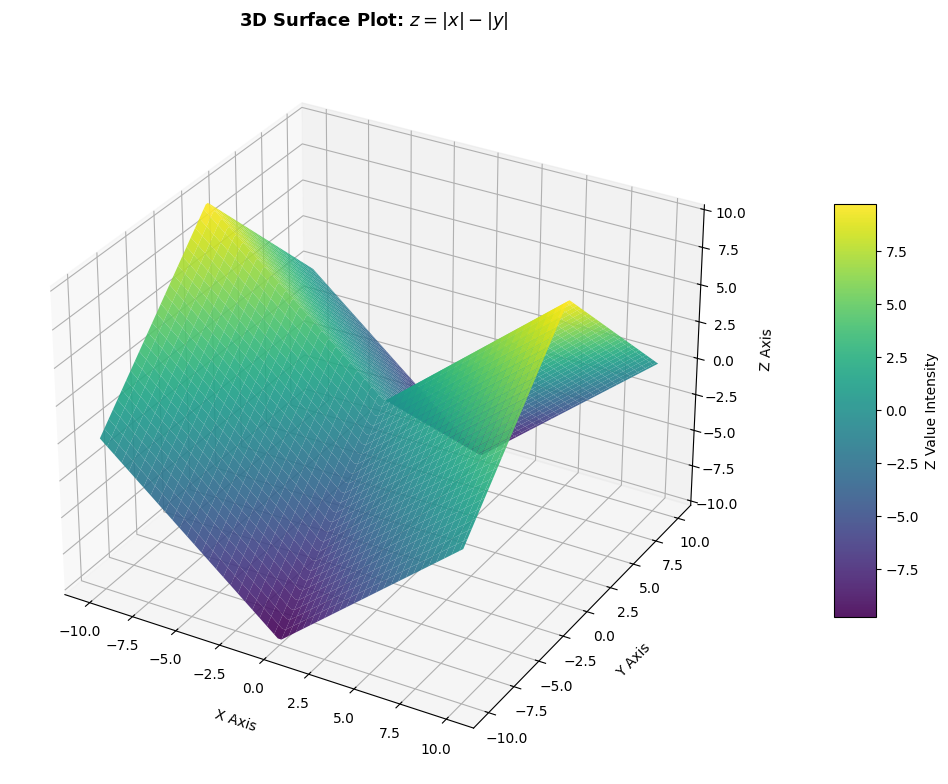

In [2]:
# 1. Define grid values for X and Y axes
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)

# Create a 2D coordinate meshgrid
X, Y = np.meshgrid(x, y)

# 2. Compute Z based on the given mathematical equation
Z = np.abs(X) - np.abs(Y)

# 3. Initialize 3D figure and axes projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Render the 3D surface plot
surf = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',        # Color palette gradient
    edgecolor='none',     # Remove gridline overlays for a smooth surface
    alpha=0.9             # Surface transparency
)

# 5. Set axis labels and plot title
ax.set_xlabel('X Axis', labelpad=10, fontsize=10)
ax.set_ylabel('Y Axis', labelpad=10, fontsize=10)
ax.set_zlabel('Z Axis', labelpad=10, fontsize=10)
ax.set_title(r'3D Surface Plot: $z = |x| - |y|$', fontsize=13, pad=15, fontweight='bold')

# 6. Add colorbar legend
cbar = fig.colorbar(surf, ax=ax, shrink=0.55, aspect=10, pad=0.1)
cbar.set_label('Z Value Intensity', fontsize=10)

# Adjust layout and render
plt.tight_layout()
plt.savefig("plots/3d_surface_abs_x_minus_abs_y.png", dpi=300, bbox_inches="tight")
plt.show()

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

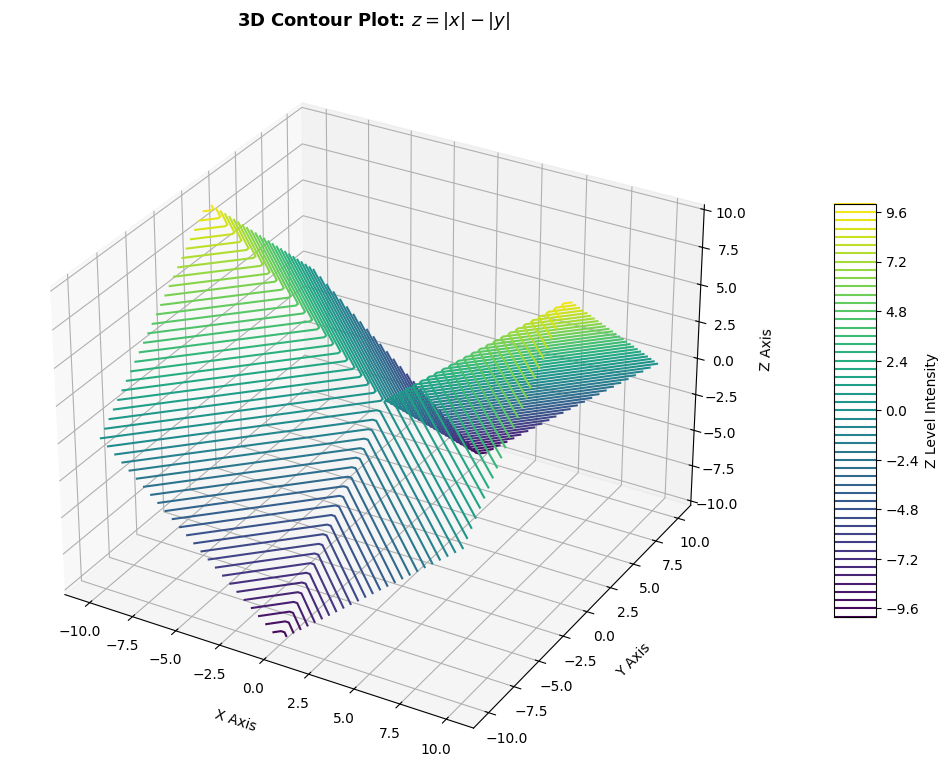

In [3]:
# 1. Define grid range for X and Y axes
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)

# Create a 2D coordinate meshgrid
X, Y = np.meshgrid(x, y)

# 2. Calculate Z based on the equation z = |x| - |y|
Z = np.abs(X) - np.abs(Y)

# 3. Initialize 3D figure and axes projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Render 3D contour lines (50 contour levels)
contour = ax.contour3D(X, Y, Z, 50, cmap='viridis')

# 5. Set axis labels and chart title
ax.set_xlabel('X Axis', labelpad=10, fontsize=10)
ax.set_ylabel('Y Axis', labelpad=10, fontsize=10)
ax.set_zlabel('Z Axis', labelpad=10, fontsize=10)
ax.set_title(r'3D Contour Plot: $z = |x| - |y|$', fontsize=13, pad=15, fontweight='bold')

# 6. Add colorbar legend for contour level intensity
cbar = fig.colorbar(contour, ax=ax, shrink=0.55, aspect=10, pad=0.1)
cbar.set_label('Z Level Intensity', fontsize=10)

# Adjust layout padding and display plot
plt.tight_layout()
plt.savefig("plots/3d_contour_abs_x_minus_abs_y.png", dpi=150, bbox_inches="tight")
plt.show()

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

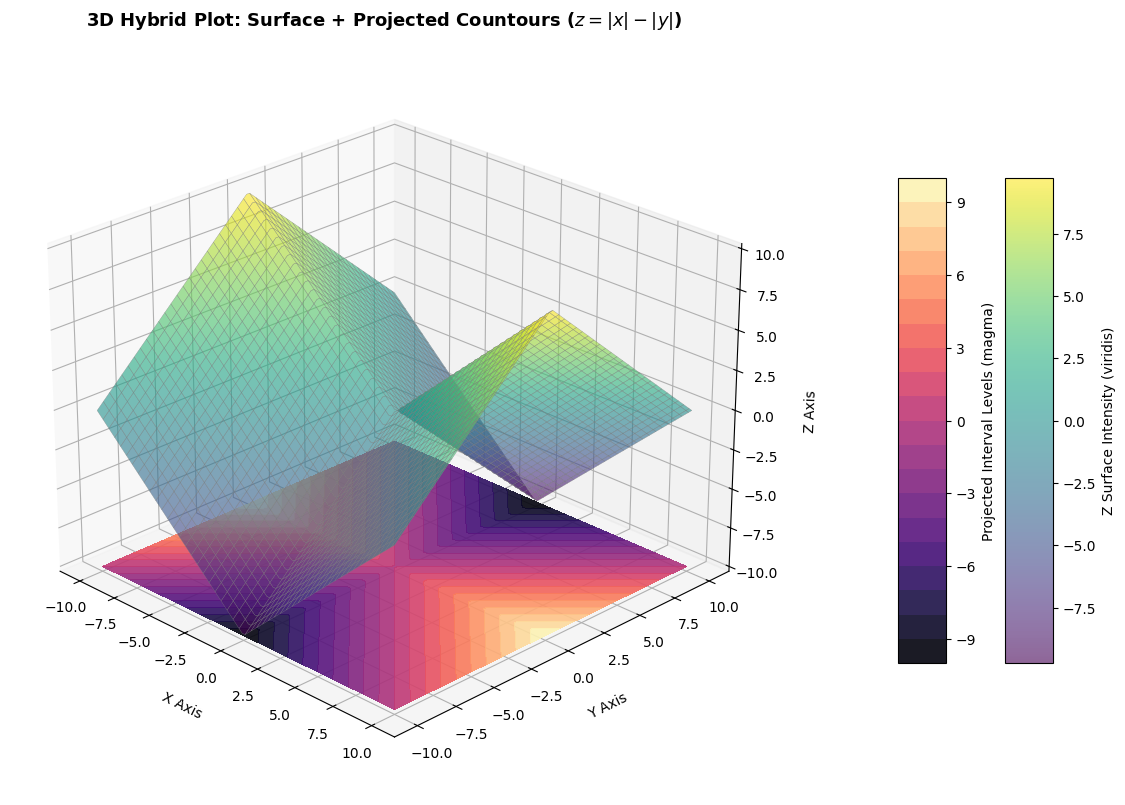

In [4]:
# 1. Define grid values for X and Y axes (-10 to 10)
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)

# Create a 2D coordinate meshgrid matrix (100x100)
X, Y = np.meshgrid(x, y)

# 2. Compute Z based on the given equation z = |x| - |y|
Z = np.abs(X) - np.abs(Y)

# 3. Define customized contour levels to highlight intervals
levels = np.linspace(-10, 10, 21) # 21 levels generate 20 filled intervals

# 4. Initialize 3D figure and axes projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 5. Render the 3D surface plot first (base layer)
# Low alpha and weak edgecolor provide structure without obscuring contours.
surf = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',        # Surface color map
    edgecolor='gray',     # Wireframe outline
    linewidth=0.2,
    alpha=0.6,             # Transparency of the surface
    antialiased=True,
    shade=True
)

# 6. Render filled contours (contourf) *projected onto the XY plane*
# zdir='z' means contours are perpendicular to the Z axis (horizontal).
# offset=-10 places the filled plot at the minimum Z boundary of the 3D box.
contour_projected = ax.contourf(
    X, Y, Z,
    levels=levels,
    cmap='magma',          # Distinct color map for the base contours
    zdir='z',
    offset=-10,             # Offset must match the min(Z) value for projection
    alpha=0.9              # Transparency of the projection
)

# 7. Customize the initial viewpoint angle
ax.view_init(elev=25, azim=-45)

# 8. Set axis labels and formatted title
ax.set_xlabel('X Axis', labelpad=10, fontsize=10)
ax.set_ylabel('Y Axis', labelpad=10, fontsize=10)
ax.set_zlabel('Z Axis', labelpad=10, fontsize=10)
ax.set_title(r'3D Hybrid Plot: Surface + Projected Countours ($z = |x| - |y|$)', fontsize=13, pad=15, fontweight='bold')

# 9. Add two separate colorbar legends
# Legend 1: Z Surface Intensity
cbar_surf = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.05, anchor=(0.0, 0.5))
cbar_surf.set_label('Z Surface Intensity (viridis)', fontsize=10)

# Legend 2: Projected Interval Levels
cbar_cont = fig.colorbar(contour_projected, ax=ax, shrink=0.5, aspect=10, pad=0.05, anchor=(1.0, 0.5))
cbar_cont.set_label('Projected Interval Levels (magma)', fontsize=10)

# Adjust layout and display render
plt.tight_layout()
plt.savefig("plots/3d_hybrid_surface_projected_contours.png", dpi=150, bbox_inches="tight")
plt.show()

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

In [10]:
df = pd.read_csv("nifty-50.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'nifty-50.csv'

In [ ]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
0,2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638122e+11,NaN
1,2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952261e+12,NaN
2,2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704094e+12,NaN
3,2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432166e+12,NaN
4,2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420158e+12,NaN


In [11]:
# 1. Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filter data for the year 2020
df_2020 = df[df['Date'].dt.year == 2020].copy()

# 3. Find top 5 stocks based on total Turnover in 2020
top_5_stocks = (
    df_2020.groupby('Symbol')['Turnover']
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

# 4. Filter the 2020 data for only these top 5 stocks
df_top5 = df_2020[df_2020['Symbol'].isin(top_5_stocks)]

# 5. Reshape using pivot_table() to safely handle duplicate entries
pivot_df = df_top5.pivot_table(
    index='Date',
    columns='Symbol',
    values='Close',
    aggfunc='mean'  # Handles duplicates by taking the average
)

# 6. Plot using Pandas plot function
fig, ax = plt.subplots(figsize=(12, 6))

pivot_df.plot(kind='line', ax=ax, linewidth=2)

# 7. Add Labels, Title, Legend, and Grid
ax.set_title('Closing Price Trend of Top 5 Stocks by Total Turnover (2020)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', labelpad=10, fontsize=10)
ax.set_ylabel('Closing Price', labelpad=10, fontsize=10)
ax.legend(title='Stock Symbol', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("plots/top5_stocks_closing_price_trend_2020.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'df' is not defined

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

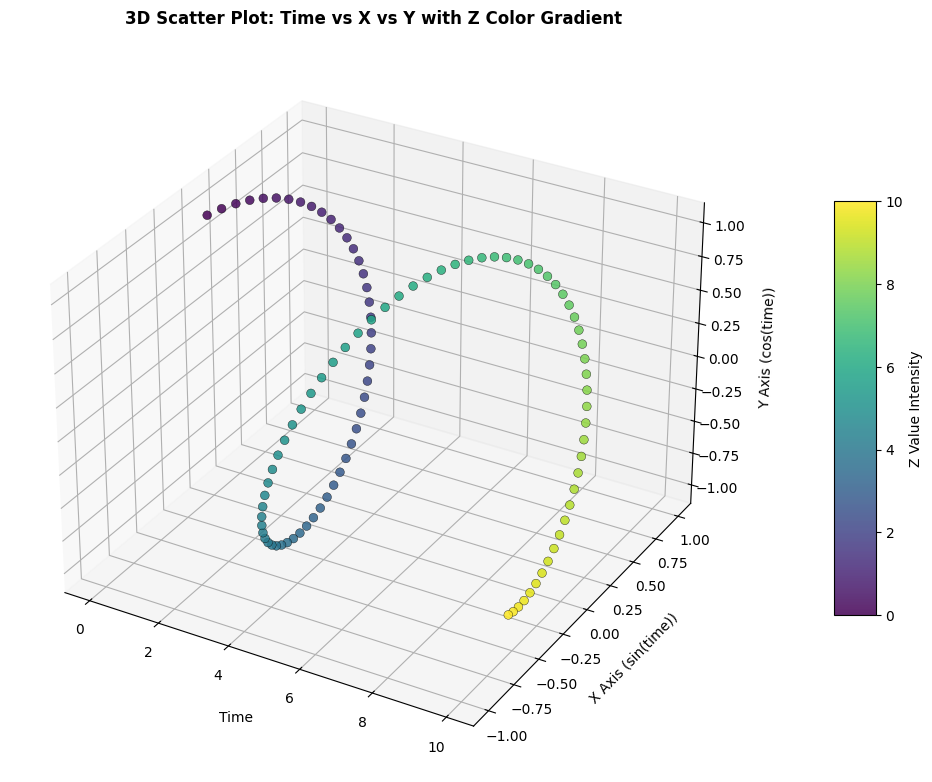

In [6]:
# 1. Create the 3D synthetic dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create DataFrame
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})

# 2. Initialize 3D figure and axes projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Render 3D scatter plot using time, x, y and apply color gradient based on z
scatter = ax.scatter3D(
    data['time'],
    data['x'],
    data['y'],
    c=data['z'],        # Map color gradient to 'z' values
    cmap='viridis',     # Continuous colormap
    s=40,               # Marker size
    alpha=0.85,         # Slight transparency for better visual depth
    edgecolor='k',      # Black border for markers to pop out
    linewidth=0.3
)

# 4. Set axis labels and chart title
ax.set_xlabel('Time', labelpad=10, fontsize=10)
ax.set_ylabel('X Axis (sin(time))', labelpad=10, fontsize=10)
ax.set_zlabel('Y Axis (cos(time))', labelpad=10, fontsize=10)
ax.set_title('3D Scatter Plot: Time vs X vs Y with Z Color Gradient', fontsize=12, pad=15, fontweight='bold')

# 5. Add colorbar legend for 'z' intensity gradient
cbar = fig.colorbar(scatter, ax=ax, shrink=0.55, aspect=10, pad=0.1)
cbar.set_label('Z Value Intensity', fontsize=10)

# Adjust layout padding and render display
plt.tight_layout()
plt.savefig("plots/3d_scatter_synthetic_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


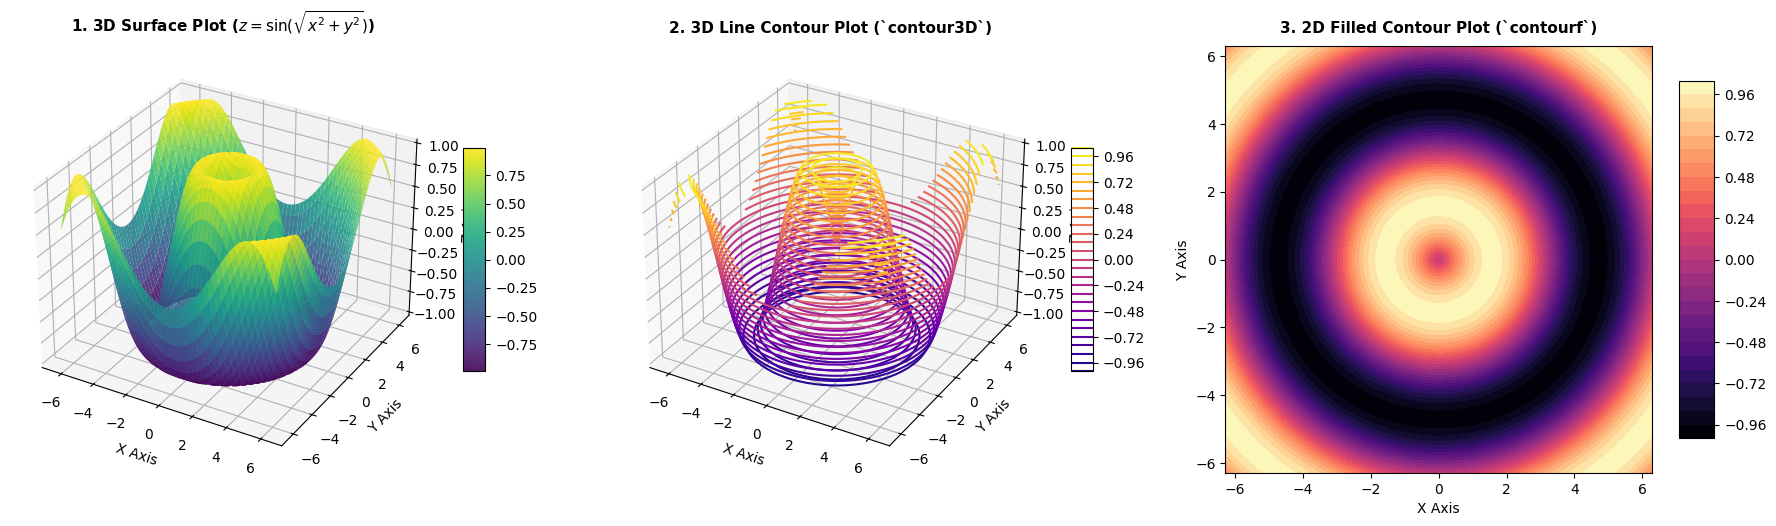

In [7]:
# 1. Define grid values for X and Y axes (-2pi to 2pi)
x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
y = np.linspace(-2 * np.pi, 2 * np.pi, 100)

# Create 2D coordinate meshgrid
X, Y = np.meshgrid(x, y)

# 2. Compute Z based on z = sin(sqrt(x^2 + y^2))
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# 3. Create a multi-plot figure canvas (1 row, 3 columns)
fig = plt.figure(figsize=(18, 5))

# -------------------------------------------------------------
# PLOT 1: 3D Surface Plot (Continuous Surface)
# -------------------------------------------------------------
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title(r'1. 3D Surface Plot ($z = \sin(\sqrt{x^2+y^2})$)', fontsize=11, pad=10, fontweight='bold')
ax1.set_xlabel('X Axis')
ax1.set_ylabel('Y Axis')
ax1.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# -------------------------------------------------------------
# PLOT 2: Contour Plot Type 1 (3D Discrete Contour Lines)
# -------------------------------------------------------------
ax2 = fig.add_subplot(132, projection='3d')
contour3d = ax2.contour3D(X, Y, Z, 30, cmap='plasma')
ax2.set_title(r'2. 3D Line Contour Plot (`contour3D`)', fontsize=11, pad=10, fontweight='bold')
ax2.set_xlabel('X Axis')
ax2.set_ylabel('Y Axis')
ax2.set_zlabel('Z Axis')
fig.colorbar(contour3d, ax=ax2, shrink=0.5, aspect=10)

# -------------------------------------------------------------
# PLOT 3: Contour Plot Type 2 (2D Filled Contour Map)
# -------------------------------------------------------------
ax3 = fig.add_subplot(133)
contourf = ax3.contourf(X, Y, Z, 30, cmap='magma')
ax3.set_title(r'3. 2D Filled Contour Plot (`contourf`)', fontsize=11, pad=10, fontweight='bold')
ax3.set_xlabel('X Axis')
ax3.set_ylabel('Y Axis')
ax3.set_aspect('equal')  # Keep circular ripple symmetry intact
fig.colorbar(contourf, ax=ax3, shrink=0.8, aspect=10)

# Adjust layout padding and render display
plt.tight_layout()
plt.savefig("plots/surface_vs_contour_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

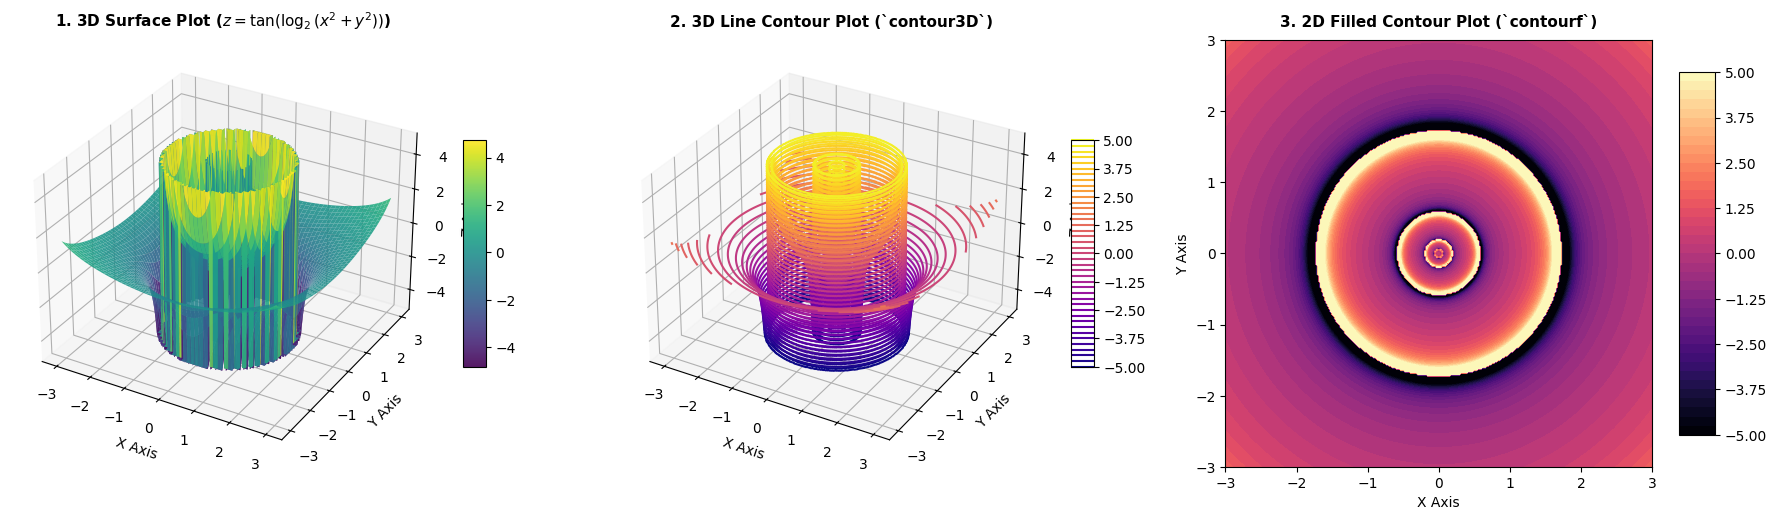

In [8]:
# 1. Define grid values for X and Y axes (excluding 0 to avoid log2(0))
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)

# Create 2D coordinate meshgrid
X, Y = np.meshgrid(x, y)

# 2. Compute Z = tan(log2(x^2 + y^2))
# Add small epsilon to prevent log2(0) division by zero
R_sq = X**2 + Y**2
R_sq[R_sq == 0] = 1e-10

Z = np.tan(np.log2(R_sq))

# Clip Z values to handle tan() asymptotes gracefully
Z = np.clip(Z, -5, 5)

# 3. Create a multi-plot figure canvas (1 row, 3 columns)
fig = plt.figure(figsize=(18, 5))

# -------------------------------------------------------------
# PLOT 1: 3D Surface Plot
# -------------------------------------------------------------
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_title(r'1. 3D Surface Plot ($z = \tan(\log_2(x^2+y^2))$)', fontsize=11, pad=10, fontweight='bold')
ax1.set_xlabel('X Axis')
ax1.set_ylabel('Y Axis')
ax1.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# -------------------------------------------------------------
# PLOT 2: Contour Plot Type 1 (3D Line Contours)
# -------------------------------------------------------------
ax2 = fig.add_subplot(132, projection='3d')
contour3d = ax2.contour3D(X, Y, Z, 40, cmap='plasma')
ax2.set_title(r'2. 3D Line Contour Plot (`contour3D`)', fontsize=11, pad=10, fontweight='bold')
ax2.set_xlabel('X Axis')
ax2.set_ylabel('Y Axis')
ax2.set_zlabel('Z Axis')
fig.colorbar(contour3d, ax=ax2, shrink=0.5, aspect=10)

# -------------------------------------------------------------
# PLOT 3: Contour Plot Type 2 (2D Filled Contour Map)
# -------------------------------------------------------------
ax3 = fig.add_subplot(133)
contourf = ax3.contourf(X, Y, Z, 40, cmap='magma')
ax3.set_title(r'3. 2D Filled Contour Plot (`contourf`)', fontsize=11, pad=10, fontweight='bold')
ax3.set_xlabel('X Axis')
ax3.set_ylabel('Y Axis')
ax3.set_aspect('equal')  # Preserve concentric circular symmetry
fig.colorbar(contourf, ax=ax3, shrink=0.8, aspect=10)

# Adjust layout padding and render display
plt.tight_layout()
plt.savefig("plots/tan_log2_surface_contour_comparison.png", dpi=150, bbox_inches="tight")
plt.show()